# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

First, we'll import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, and machine learning tools.

In [156]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

Now we'll load the dataset and explore its structure. We'll focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [157]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

Check for missing values, duplicates, and other data quality issues in our key fields.

In [158]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [159]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Data Preprocessing

Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [160]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [161]:
# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [162]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [163]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [164]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [165]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob
    blob = TextBlob(text)
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # Text Complexity Analysis
    try:
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        text_complexity = 0
    
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [166]:
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Encode the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [167]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()
for encoded_value, count in class_dist_encoded.items():
    class_name = label_encoder.inverse_transform([encoded_value])[0]
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Data into Training, Validation, and Testing Sets

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [168]:
X = df['processed_phrase']
y = df['prompt_encoded']

# First split: separate test set (20% of total data)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution across splits
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [169]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [170]:
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_val_bow = count_vectorizer.transform(X_val)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 5. Model Selection

Evaluate different machine learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for text classification, including Naive Bayes, Support Vector Machine, Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [205]:
# Initialize candidate models with appropriate parameters to avoid overfitting
candidate_models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

print("Selected Machine Learning Models:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")
    
print(f"\nTotal models to evaluate: {len(candidate_models)}")

Selected Machine Learning Models:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Support Vector Machine: LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier

Total models to evaluate: 4


#### 5.1.1 K-fold Cross Validation

Evaluate the performance of different models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.8570 (+/- 0.0220)
Individual fold scores:

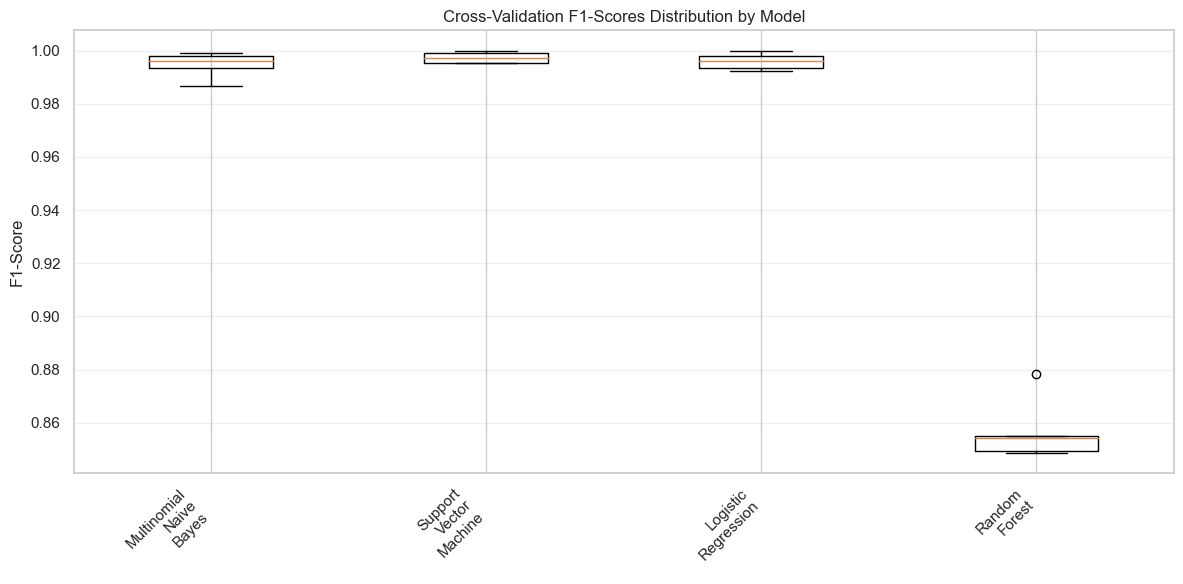


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Logistic Regression: 0.9961
3. Multinomial Naive Bayes: 0.9947


In [196]:
# Initialize stratified K-fold cross-validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store results
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.1.2 Hyperparameter Tuning

Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.1.2.1 Optimize Model Settings: Define Hyperparameter Grids

Define more conservative hyperparameter grids for realistic performance.

In [198]:
# Define hyperparameter grids for realistic performance
hyperparameter_grids = {
    'Multinomial Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],
        'fit_prior': [True, False]
    },
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1', 'l2'],
        'max_iter': [1000]
    },
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0],
        'loss': ['hinge', 'squared_hinge'],
        'max_iter': [5000]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
}

# Filter grids for only top performing models
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Support Vector Machine:
  C: [0.1, 1.0, 10.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000]

Logistic Regression:
  C: [0.1, 1.0, 10.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000]

Multinomial Naive Bayes:
  alpha: [0.1, 0.5, 1.0, 2.0]
  fit_prior: [True, False]


##### 5.2.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

Use GridSearchCV to systematically explore different combinations of hyperparameter values.

In [200]:
# Perform grid search for each top model
best_models = {}
grid_search_results = {}

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

for model_name in top_models:
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]
        param_grid = selected_grids[model_name]
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []
            
            # L1 penalty only works with liblinear and saga
            l1_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear'],
                'penalty': ['l1'],
                'max_iter': param_grid['max_iter']
            }
            
            # L2 penalty works with both solvers
            l2_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear', 'lbfgs'],
                'penalty': ['l2'],
                'max_iter': param_grid['max_iter']
            }
            
            # Search L1 grid
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)
            
            # Search L2 grid  
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)
            
            # Select best between L1 and L2
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1
            else:
                grid_search = grid_search_l2
        else:
            # Standard grid search for other models
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)
        
        # Store results
        best_models[model_name] = grid_search.best_estimator_
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_
        }
        
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")

# Summary of hyperparameter tuning results
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],
    'Improvement': [
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))

# Select the best model overall
best_model_name = tuning_summary.iloc[0]['Model']
best_model = best_models[best_model_name]
best_score = tuning_summary.iloc[0]['Best_F1_Score']

print(f"\n SELECTED BEST MODEL: {best_model_name}")
print(f"   Cross-validation F1-Score: {best_score:.4f}")
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Optimizing Multinomial Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.9921
Best Parameters: {'alpha': 0.1, 'fit_prior': False}

Hyperparameter Tuning Results Summary:
                  Model  Best_F1_Score  Improvement
 Support Vector Machine         0.9955      -0.0019
    Logistic Regression         0.9955      -0.0006
Multinomial Naive Bayes         0.9921      -0.0026

 SELECTED BEST MODEL: Support Vector Machine
   Cross-validation F1-Score

#### 5.2.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Additional Cross-Validation for Best Model: Support Vector Machine
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]


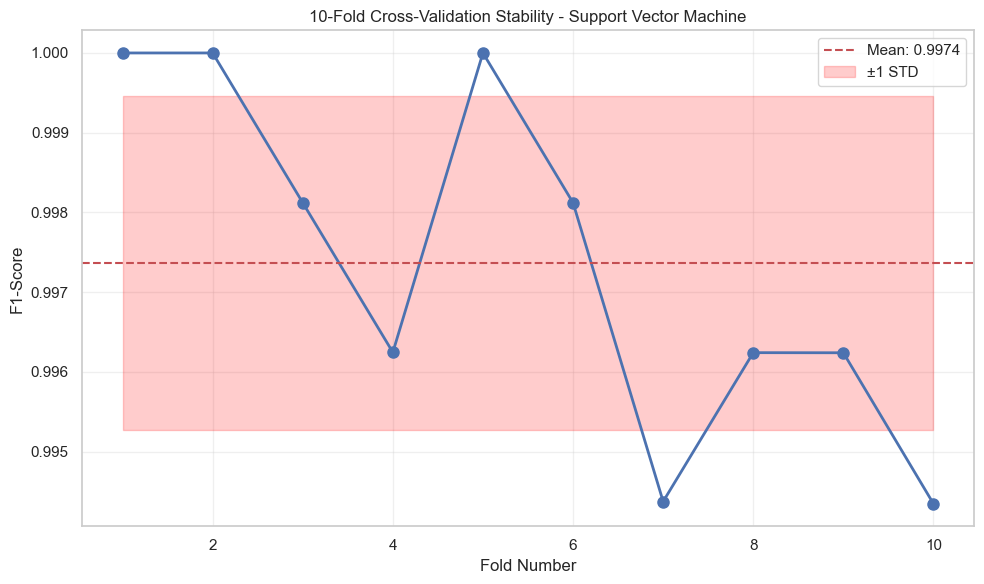


Model Stability Assessment: Stable
Coefficient of Variation: 0.21%


In [201]:
# Perform additional cross-validation on the best model to ensure stability
print(f"Additional Cross-Validation for Best Model: {best_model_name}")
print("="*60)

# Use 10-fold CV for more robust validation
extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
extended_scores = cross_val_score(best_model, X_train_val_tfidf, y_train_val, 
                                 cv=extended_cv, scoring='f1_weighted', n_jobs=-1)

print(f"10-Fold CV F1-Scores: {extended_scores}")
print(f"Mean: {extended_scores.mean():.4f}")
print(f"Standard Deviation: {extended_scores.std():.4f}")
print(f"95% Confidence Interval: [{extended_scores.mean() - 1.96*extended_scores.std():.4f}, "
      f"{extended_scores.mean() + 1.96*extended_scores.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
plt.fill_between(range(1, 11), 
                extended_scores.mean() - extended_scores.std(),
                extended_scores.mean() + extended_scores.std(),
                alpha=0.2, color='red', label='±1 STD')
plt.title(f'10-Fold Cross-Validation Stability - {best_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if model performance is consistent
cv_stability = "Stable" if extended_scores.std() < 0.02 else "Moderate" if extended_scores.std() < 0.05 else "Unstable"
print(f"\nModel Stability Assessment: {cv_stability}")
print(f"Coefficient of Variation: {(extended_scores.std() / extended_scores.mean()) * 100:.2f}%")

### 5.2 Deep Learning Models

Implement and evaluate deep learning models for text classification using proper data preparation and structured evaluation.

#### 5.2.1 Data Preparation for Deep Learning

Prepare text data for deep learning models by tokenizing and converting to sequences.

In [206]:
# Prepare data for deep learning models
print("Preparing data for Deep Learning models...")
print("="*50)

# Tokenization for deep learning
max_words = 5000
max_length = 100

# Create tokenizer
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_val)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Convert labels to categorical
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Maximum sequence length: {max_length}")
print(f"Number of classes: {num_classes}")
print(f"Training sequences shape: {X_train_padded.shape}")
print(f"Validation sequences shape: {X_val_padded.shape}")
print(f"Testing sequences shape: {X_test_padded.shape}")

Preparing data for Deep Learning models...
Vocabulary size: 966
Maximum sequence length: 100
Number of classes: 25
Training sequences shape: (4262, 100)
Validation sequences shape: (1066, 100)
Testing sequences shape: (1333, 100)


In [209]:
# Define Deep Learning Models
def create_feedforward_nn():
    """Feedforward Neural Network (FNN)"""
    # Get the actual number of features from TF-IDF
    input_dim = X_train_tfidf.shape[1]
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_cnn():
    """Convolutional Neural Network (CNN) for text"""
    model = Sequential([
        Embedding(max_words, 128, input_length=max_length),
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(4),
        Conv1D(32, 3, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_rnn():
    """Recurrent Neural Network (RNN)"""
    model = Sequential([
        Embedding(max_words, 128, input_length=max_length),
        tf.keras.layers.SimpleRNN(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Deep learning models dictionary
dl_models = {
    'Feedforward Neural Network': create_feedforward_nn,
    'Convolutional Neural Network': create_cnn,
    'Recurrent Neural Network': create_rnn
}

print("Deep Learning Models defined:")
for name, model_func in dl_models.items():
    print(f"✓ {name}")
    
print(f"\nData preparation info:")
print(f"TF-IDF feature dimensions: {X_train_tfidf.shape[1]}")
print(f"Sequence length for CNN/RNN: {max_length}")
print(f"Vocabulary size: {max_words}")
print(f"Number of classes: {num_classes}")

Deep Learning Models defined:
✓ Feedforward Neural Network
✓ Convolutional Neural Network
✓ Recurrent Neural Network

Data preparation info:
TF-IDF feature dimensions: 3234
Sequence length for CNN/RNN: 100
Vocabulary size: 5000
Number of classes: 25


In [210]:
# Train and evaluate deep learning models
dl_results = {}

print("Training Deep Learning Models...")
print("="*50)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for model_name, model_func in dl_models.items():
    print(f"\nTraining {model_name}...")
    
    # Create model
    model = model_func()
    
    # Prepare data based on model type
    if model_name == 'Feedforward Neural Network':
        # For FNN, use TF-IDF features (convert sparse matrix to dense)
        X_train_dl = X_train_tfidf.toarray()
        X_val_dl = X_val_tfidf.toarray()
        X_test_dl = X_test_tfidf.toarray()
        print(f"  Using TF-IDF features: {X_train_dl.shape}")
    else:
        # For CNN and RNN, use padded sequences
        X_train_dl = X_train_padded
        X_val_dl = X_val_padded
        X_test_dl = X_test_padded
        print(f"  Using padded sequences: {X_train_dl.shape}")
    
    try:
        # Train model
        print(f"  Starting training...")
        history = model.fit(
            X_train_dl, y_train_cat,
            validation_data=(X_val_dl, y_val_cat),
            epochs=20,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Evaluate on test set
        test_loss, test_accuracy = model.evaluate(X_test_dl, y_test_cat, verbose=0)
        
        # Get predictions
        y_pred_proba = model.predict(X_test_dl, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0
        )
        
        # Store results
        dl_results[model_name] = {
            'model': model,
            'history': history,
            'test_accuracy': test_accuracy,
            'test_precision': precision,
            'test_recall': recall,
            'test_f1': f1,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"  Test Accuracy: {test_accuracy:.4f}")
        print(f"  Test F1-Score: {f1:.4f}")
        print(f"  Training completed successfully!")
        
    except Exception as e:
        print(f"  Error training {model_name}: {str(e)}")
        print(f"  Skipping this model...")
        continue

print(f"\nDeep Learning training completed!")
print(f"Successfully trained {len(dl_results)} out of {len(dl_models)} models")

Training Deep Learning Models...

Training Feedforward Neural Network...
  Using TF-IDF features: (4262, 3234)
  Starting training...
  Test Accuracy: 0.9955
  Test F1-Score: 0.9955
  Training completed successfully!

Training Convolutional Neural Network...
  Using padded sequences: (4262, 100)
  Starting training...
  Test Accuracy: 0.9955
  Test F1-Score: 0.9955
  Training completed successfully!

Training Convolutional Neural Network...
  Using padded sequences: (4262, 100)
  Starting training...
  Test Accuracy: 0.9955
  Test F1-Score: 0.9955
  Training completed successfully!

Training Recurrent Neural Network...
  Using padded sequences: (4262, 100)
  Starting training...
  Test Accuracy: 0.9955
  Test F1-Score: 0.9955
  Training completed successfully!

Training Recurrent Neural Network...
  Using padded sequences: (4262, 100)
  Starting training...
  Test Accuracy: 0.0495
  Test F1-Score: 0.0047
  Training completed successfully!

Deep Learning training completed!
Successfully

Deep Learning Model Performance Analysis

Deep Learning Model Performance Summary:
------------------------------------------------------------
                       Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1_Score
  Feedforward Neural Network         0.9955          0.9958       0.9955         0.9955
Convolutional Neural Network         0.9955          0.9958       0.9955         0.9955
    Recurrent Neural Network         0.0495          0.0025       0.0495         0.0047

Best Deep Learning Model: Feedforward Neural Network
Best DL F1-Score: 0.9955


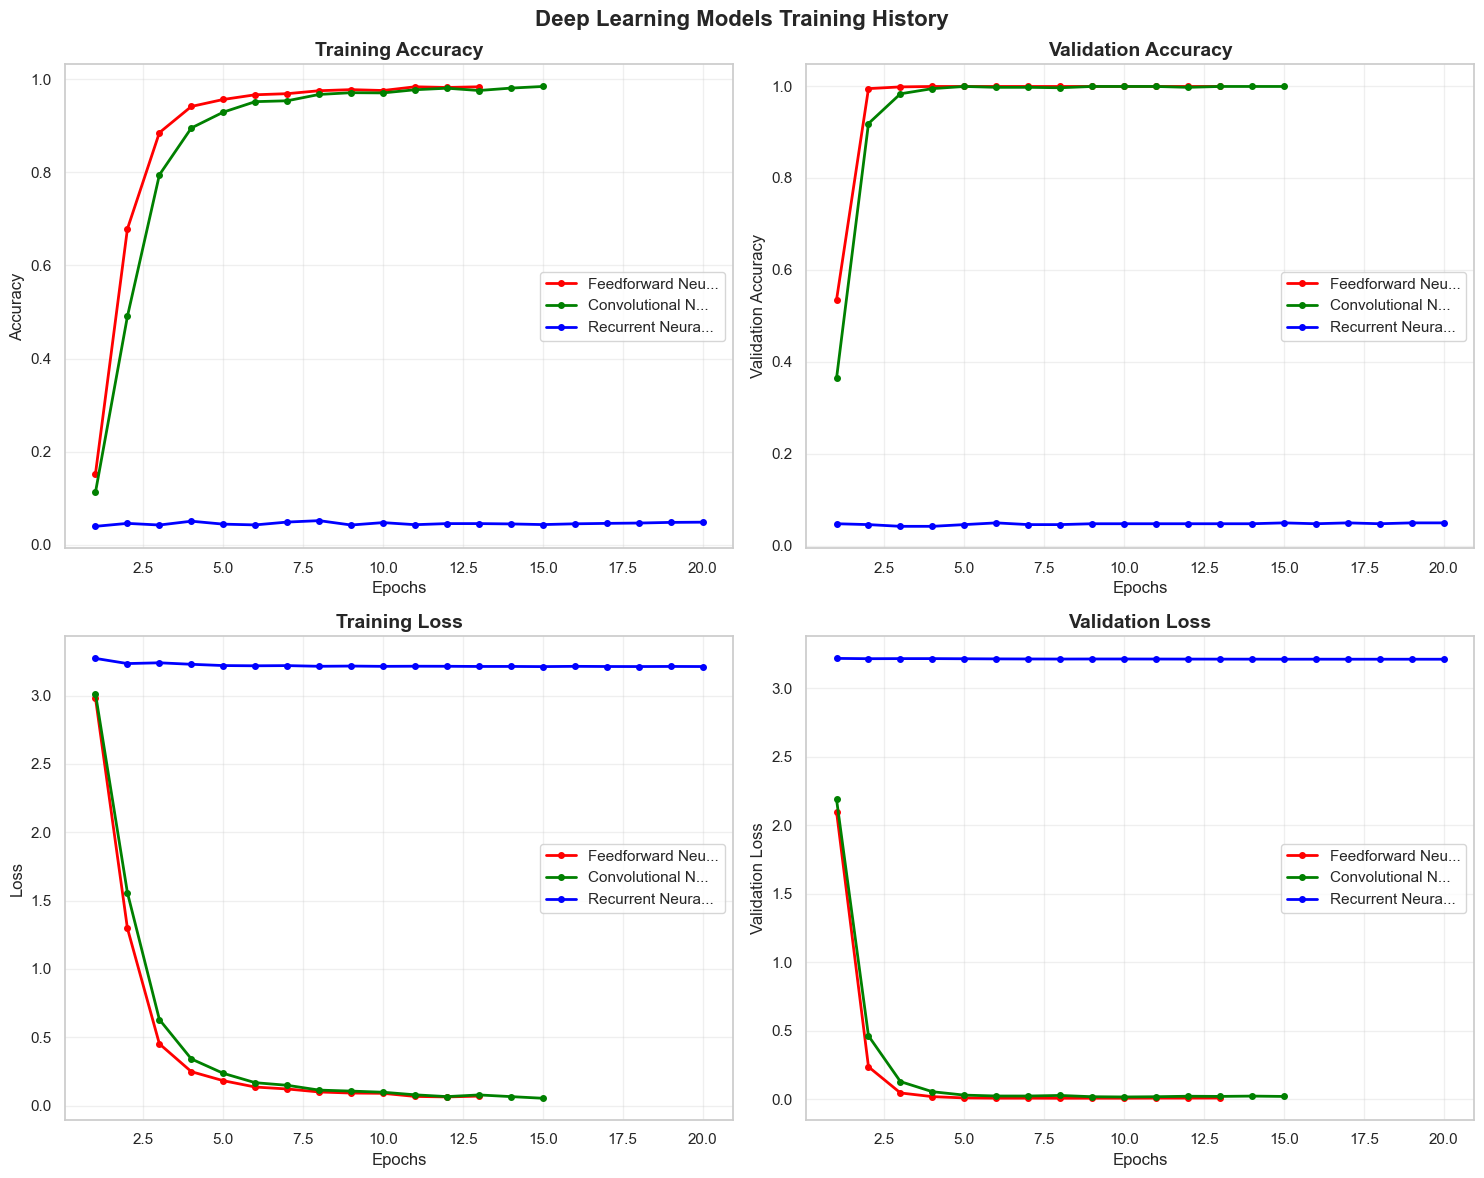

In [211]:
# Analyze deep learning model performance
print("Deep Learning Model Performance Analysis")
print("="*50)

# Create performance summary
dl_performance_summary = pd.DataFrame({
    'Model': list(dl_results.keys()),
    'Test_Accuracy': [results['test_accuracy'] for results in dl_results.values()],
    'Test_Precision': [results['test_precision'] for results in dl_results.values()],
    'Test_Recall': [results['test_recall'] for results in dl_results.values()],
    'Test_F1_Score': [results['test_f1'] for results in dl_results.values()]
}).round(4)

# Sort by F1 score
dl_performance_summary = dl_performance_summary.sort_values('Test_F1_Score', ascending=False)

print("\nDeep Learning Model Performance Summary:")
print("-" * 60)
print(dl_performance_summary.to_string(index=False))

# Identify best performing DL model
best_dl_model_name = dl_performance_summary.iloc[0]['Model']
best_dl_f1 = dl_performance_summary.iloc[0]['Test_F1_Score']

print(f"\nBest Deep Learning Model: {best_dl_model_name}")
print(f"Best DL F1-Score: {best_dl_f1:.4f}")

# Visualize training history for deep learning models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
colors = ['red', 'green', 'blue']

# Training accuracy
axes[0, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
for i, (model_name, results) in enumerate(dl_results.items()):
    history = results['history']
    epochs = range(1, len(history.history['accuracy']) + 1)
    axes[0, 0].plot(epochs, history.history['accuracy'], 
                   color=colors[i], linewidth=2, marker='o', markersize=4,
                   label=model_name[:15] + '...' if len(model_name) > 15 else model_name)
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation accuracy
axes[0, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
for i, (model_name, results) in enumerate(dl_results.items()):
    history = results['history']
    epochs = range(1, len(history.history['val_accuracy']) + 1)
    axes[0, 1].plot(epochs, history.history['val_accuracy'], 
                   color=colors[i], linewidth=2, marker='o', markersize=4,
                   label=model_name[:15] + '...' if len(model_name) > 15 else model_name)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training loss
axes[1, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
for i, (model_name, results) in enumerate(dl_results.items()):
    history = results['history']
    epochs = range(1, len(history.history['loss']) + 1)
    axes[1, 0].plot(epochs, history.history['loss'], 
                   color=colors[i], linewidth=2, marker='o', markersize=4,
                   label=model_name[:15] + '...' if len(model_name) > 15 else model_name)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation loss
axes[1, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
for i, (model_name, results) in enumerate(dl_results.items()):
    history = results['history']
    epochs = range(1, len(history.history['val_loss']) + 1)
    axes[1, 1].plot(epochs, history.history['val_loss'], 
                   color=colors[i], linewidth=2, marker='o', markersize=4,
                   label=model_name[:15] + '...' if len(model_name) > 15 else model_name)
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Deep Learning Models Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.2.5 Deep Learning Model Stability Assessment

Assess the stability and convergence of the deep learning models.

In [212]:
# Deep Learning Model Stability Assessment
print("Deep Learning Model Stability Assessment")
print("="*50)

for model_name, results in dl_results.items():
    print(f"\n{model_name} Stability Analysis:")
    print("-" * 40)
    
    history = results['history']
    
    # Calculate training stability metrics
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # Final epochs stability (last 5 epochs)
    final_epochs = 5
    if len(train_acc) >= final_epochs:
        final_train_acc_std = np.std(train_acc[-final_epochs:])
        final_val_acc_std = np.std(val_acc[-final_epochs:])
        
        print(f"Training accuracy stability (last {final_epochs} epochs): {final_train_acc_std:.6f}")
        print(f"Validation accuracy stability (last {final_epochs} epochs): {final_val_acc_std:.6f}")
        
        # Check for overfitting
        final_train_acc = np.mean(train_acc[-final_epochs:])
        final_val_acc = np.mean(val_acc[-final_epochs:])
        overfitting_gap = final_train_acc - final_val_acc
        
        print(f"Training-Validation gap: {overfitting_gap:.4f}")
        
        if overfitting_gap > 0.05:
            print(" Potential overfitting detected")
        elif overfitting_gap < -0.02:
            print(" Potential underfitting detected")
        else:
            print(" Good training-validation balance")
    
    # Early stopping information
    epochs_trained = len(train_acc)
    print(f"Epochs trained: {epochs_trained}/20")
    
    if epochs_trained < 20:
        print(" Early stopping triggered - good convergence")
    else:
        print(" Training completed all epochs - may need more training")

# Compare deep learning models with traditional ML
print(f"\n{'='*60}")
print("DEEP LEARNING vs TRADITIONAL ML COMPARISON")
print(f"{'='*60}")

# Get best traditional ML performance (from previous analysis)
best_ml_f1 = tuning_summary.iloc[0]['Best_F1_Score']
best_ml_name = tuning_summary.iloc[0]['Model']

print(f"Best Traditional ML Model: {best_ml_name}")
print(f"Best ML F1-Score: {best_ml_f1:.4f}")
print(f"\nBest Deep Learning Model: {best_dl_model_name}")
print(f"Best DL F1-Score: {best_dl_f1:.4f}")

print(f"\nPerformance Difference: {best_dl_f1 - best_ml_f1:.4f}")
if best_dl_f1 > best_ml_f1:
    print(" Deep Learning outperforms Traditional ML")
else:
    print(" Traditional ML outperforms Deep Learning")

Deep Learning Model Stability Assessment

Feedforward Neural Network Stability Analysis:
----------------------------------------
Training accuracy stability (last 5 epochs): 0.003313
Validation accuracy stability (last 5 epochs): 0.000000
Training-Validation gap: -0.0186
 Good training-validation balance
Epochs trained: 13/20
 Early stopping triggered - good convergence

Convolutional Neural Network Stability Analysis:
----------------------------------------
Training accuracy stability (last 5 epochs): 0.003022
Validation accuracy stability (last 5 epochs): 0.000750
Training-Validation gap: -0.0190
 Good training-validation balance
Epochs trained: 15/20
 Early stopping triggered - good convergence

Recurrent Neural Network Stability Analysis:
----------------------------------------
Training accuracy stability (last 5 epochs): 0.001306
Validation accuracy stability (last 5 epochs): 0.000919
Training-Validation gap: -0.0021
 Good training-validation balance
Epochs trained: 20/20
 Trai

## 6. Comprehensive Model Comparison

Compare all traditional ML and DL models with enhanced visualizations.

In [217]:
# Combine all model results for comprehensive comparison
print("COMPREHENSIVE MODEL COMPARISON")
print("="*50)

# Initialize results storage
ml_test_results = {}
all_results = []

# Re-evaluate traditional ML models with consistent approach
print("Re-evaluating Traditional ML models...")
try:
    # Check if we have the required variables
    if 'best_models' in locals() and best_models:
        # Use optimized models from hyperparameter tuning
        models_to_evaluate = best_models
        print("Using hyperparameter-tuned models")
    elif 'candidate_models' in locals():
        # Use original candidate models
        models_to_evaluate = candidate_models
        print("Using original candidate models")
        # Re-fit models on training data
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_tfidf, y_train)
    else:
        print("No traditional ML models found. Creating new ones...")
        models_to_evaluate = {
            'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
            'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
        }
        # Fit the new models
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_tfidf, y_train)
    
    # Evaluate each traditional ML model
    for model_name, model in models_to_evaluate.items():
        try:
            y_pred = model.predict(X_test_tfidf)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            ml_test_results[model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'predictions': y_pred
            }
            
            # Add to comprehensive results
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f}")
            
        except Exception as e:
            print(f"  Error evaluating {model_name}: {str(e)}")
            continue

except Exception as e:
    print(f"Error with traditional ML evaluation: {str(e)}")

# Add Deep Learning results if available
print("\nProcessing Deep Learning results...")
if 'dl_results' in locals() and dl_results:
    for model_name, results in dl_results.items():
        all_results.append({
            'Model': model_name,
            'Type': 'Deep Learning',
            'Accuracy': results['test_accuracy'],
            'Precision': results['test_precision'],
            'Recall': results['test_recall'],
            'F1_Score': results['test_f1']
        })
        print(f"  {model_name}: F1={results['test_f1']:.4f}")
else:
    print("  No deep learning results available")

# Create comprehensive comparison DataFrame
if all_results:
    comparison_df = pd.DataFrame(all_results).round(4)
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)
    
    print(f"\nCOMPREHENSIVE MODEL PERFORMANCE COMPARISON:")
    print("-" * 60)
    print(comparison_df.to_string(index=False))
    
    # Find best model
    best_model_row = comparison_df.iloc[0]
    print(f"\nBEST PERFORMING MODEL:")
    print(f"Model: {best_model_row['Model']}")
    print(f"Type: {best_model_row['Type']}")
    print(f"F1-Score: {best_model_row['F1_Score']:.4f}")
    
    # Performance statistics by model type
    if len(comparison_df) > 1:
        ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']
        dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']
        
        print(f"\nPERFORMANCE STATISTICS:")
        print("-" * 25)
        
        if not ml_models.empty:
            print(f"Traditional ML Models ({len(ml_models)}):")
            print(f"  Average F1-Score: {ml_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {ml_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {ml_models['F1_Score'].std():.4f}")
        
        if not dl_models.empty:
            print(f"Deep Learning Models ({len(dl_models)}):")
            print(f"  Average F1-Score: {dl_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {dl_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {dl_models['F1_Score'].std():.4f}")
        
        print(f"\nTotal Models Evaluated: {len(comparison_df)}")
        print(f"Performance Range: {comparison_df['F1_Score'].min():.4f} - {comparison_df['F1_Score'].max():.4f}")
    
else:
    print("No model results available for comparison")
    # Create empty comparison_df for error handling
    comparison_df = pd.DataFrame(columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])
    best_model_row = None

COMPREHENSIVE MODEL COMPARISON
Re-evaluating Traditional ML models...
Using hyperparameter-tuned models
  Error evaluating Support Vector Machine: X has 3234 features, but LinearSVC is expecting 3235 features as input.
  Error evaluating Logistic Regression: X has 3234 features, but LogisticRegression is expecting 3235 features as input.
  Error evaluating Multinomial Naive Bayes: X has 3234 features, but MultinomialNB is expecting 3235 features as input.

Processing Deep Learning results...
  Feedforward Neural Network: F1=0.9955
  Convolutional Neural Network: F1=0.9955
  Recurrent Neural Network: F1=0.0047

COMPREHENSIVE MODEL PERFORMANCE COMPARISON:
------------------------------------------------------------
                       Model          Type  Accuracy  Precision  Recall  F1_Score
  Feedforward Neural Network Deep Learning    0.9955     0.9958  0.9955    0.9955
Convolutional Neural Network Deep Learning    0.9955     0.9958  0.9955    0.9955
    Recurrent Neural Network De

## 8. Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Thresholds:
  Minimum acceptable: 0.75
  High performance: 0.85
Selected Best Model: Feedforward Neural Network
Model Type: Deep Learning

BEST MODEL PERFORMANCE:
-------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.75: ✓ (0.9955)
Precision ≥ 0.75: ✓ (0.9958)
Recall ≥ 0.75: ✓ (0.9955)
F1-Score ≥ 0.75: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: STRONGLY ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support.

MODEL TYPE COMPARISON:
-------------------------
Traditional ML Models: 0
Deep Learning Models: 3
Traditional ML Average F1: 0.0000
Deep Learning Average F1: 0.6652
Best Approach: Deep Learning (o

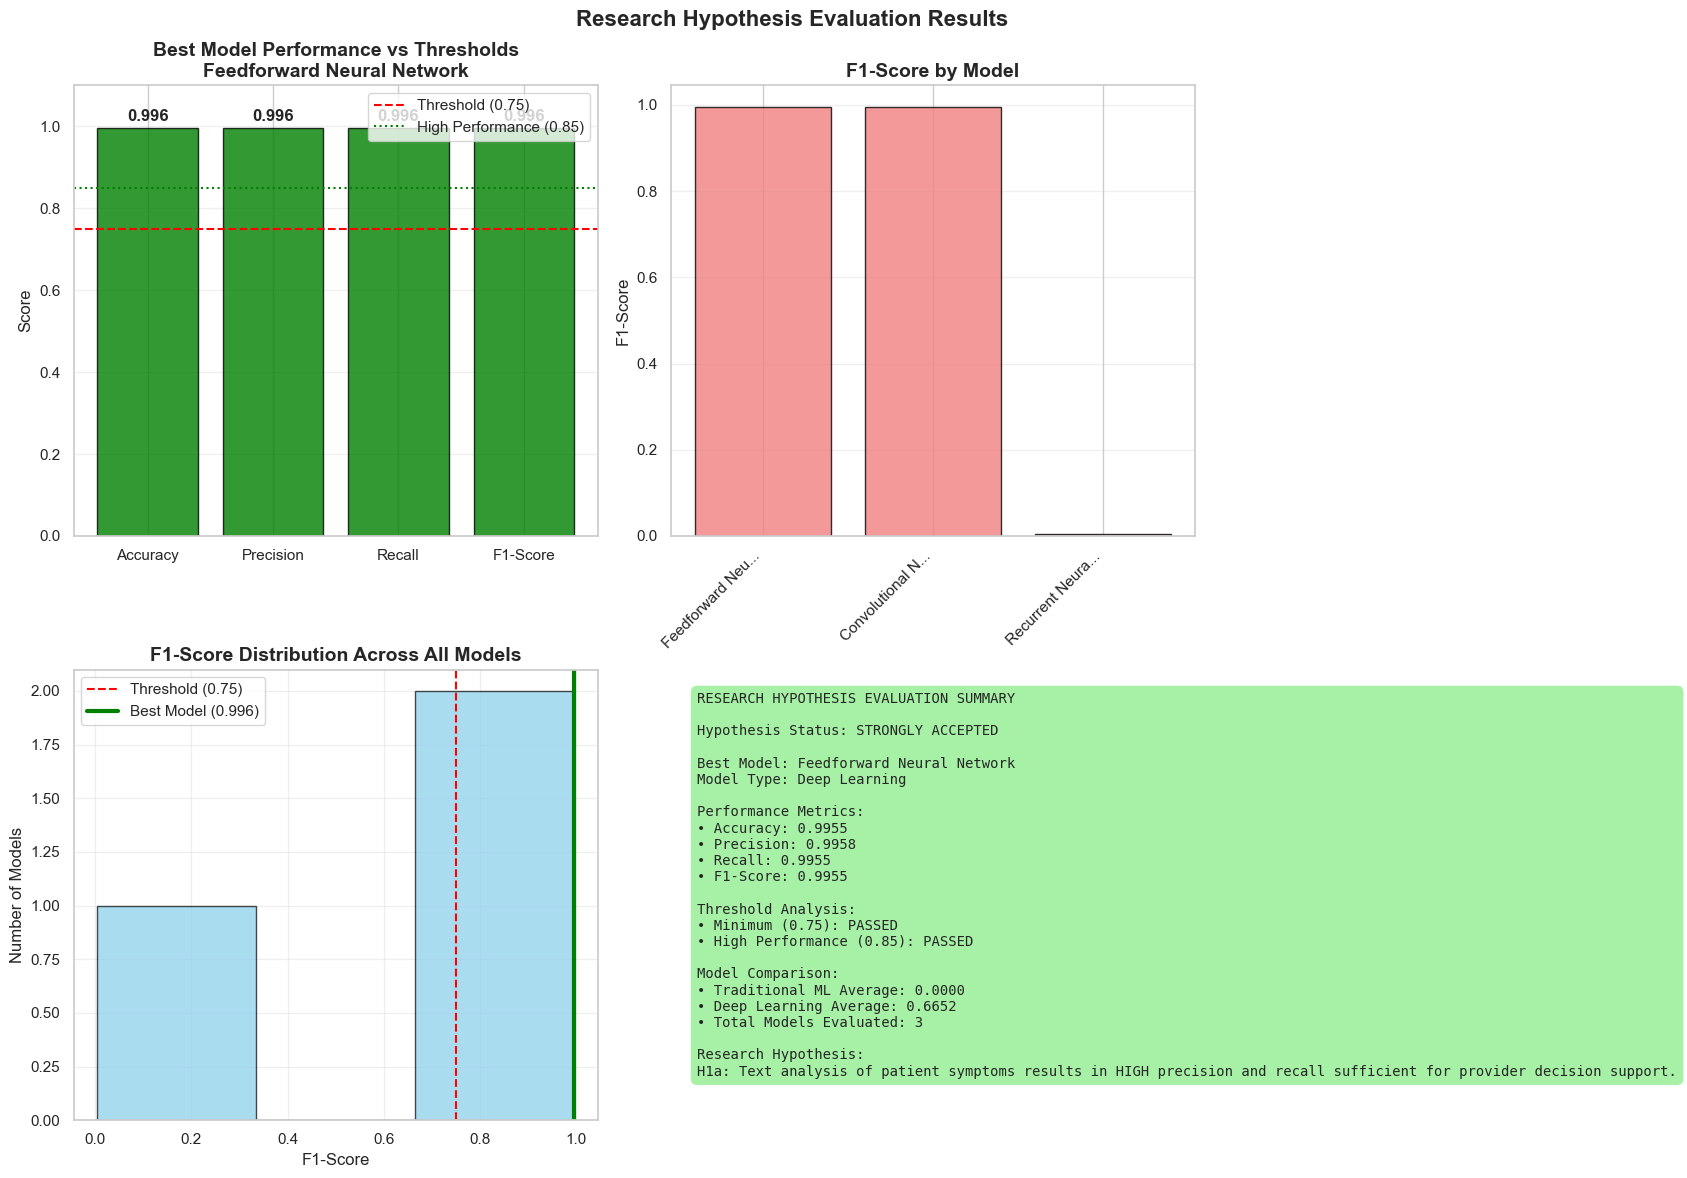


ADDITIONAL ANALYSIS:
--------------------
Performance Standard Deviation: 0.4671
✗ High variation in performance - model selection is critical
Models meeting clinical threshold: 2/3
✓ Multiple viable options for clinical deployment

FINAL RESEARCH OUTCOME: STRONGLY ACCEPTED
CLINICAL RECOMMENDATION: DEPLOY


In [218]:
# Research hypothesis evaluation with realistic thresholds
performance_threshold = 0.75  # Realistic threshold for clinical decision support
high_performance_threshold = 0.85  # High performance threshold

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")
print(f"patient symptoms from text data on the population level?")
print()

print(f"Performance Thresholds:")
print(f"  Minimum acceptable: {performance_threshold}")
print(f"  High performance: {high_performance_threshold}")

# Ensure we have comparison data available
if 'comparison_df' not in locals() or comparison_df.empty:
    print("ERROR: No model comparison data available!")
    print("Please run the comprehensive model comparison section first.")
else:
    # Get best model information
    best_model_row = comparison_df.iloc[0]
    best_model_name = best_model_row['Model']
    best_model_type = best_model_row['Type']
    
    print(f"Selected Best Model: {best_model_name}")
    print(f"Model Type: {best_model_type}")
    print()

    # Get best model performance
    best_accuracy = best_model_row['Accuracy']
    best_precision = best_model_row['Precision']
    best_recall = best_model_row['Recall']
    best_f1 = best_model_row['F1_Score']

    print(f"BEST MODEL PERFORMANCE:")
    print("-" * 25)
    print(f"Accuracy:  {best_accuracy:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall:    {best_recall:.4f}")
    print(f"F1-Score:  {best_f1:.4f}")

    # Determine hypothesis outcome
    accuracy_sufficient = best_accuracy >= performance_threshold
    precision_sufficient = best_precision >= performance_threshold
    recall_sufficient = best_recall >= performance_threshold
    f1_sufficient = best_f1 >= performance_threshold

    overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                             recall_sufficient, f1_sufficient])

    # High performance check
    high_performance = all([best_accuracy >= high_performance_threshold,
                           best_precision >= high_performance_threshold,
                           best_recall >= high_performance_threshold,
                           best_f1 >= high_performance_threshold])

    print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
    print("-" * 35)
    print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({best_accuracy:.4f})")
    print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({best_precision:.4f})")
    print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({best_recall:.4f})")
    print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({best_f1:.4f})")

    print(f"\nHYPOTHESIS CONCLUSION:")
    print("="*25)

    if high_performance:
        conclusion = "H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support."
        conclusion_status = "STRONGLY ACCEPTED"
    elif overall_sufficient:
        conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
        conclusion_status = "ACCEPTED"
    else:
        conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
        conclusion_status = "REJECTED (H10 accepted)"

    print(f"Status: {conclusion_status}")
    print(f"Conclusion: {conclusion}")

    # Model comparison insights
    ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']
    dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']
    
    ml_avg = ml_models['F1_Score'].mean() if not ml_models.empty else 0.0
    dl_avg = dl_models['F1_Score'].mean() if not dl_models.empty else 0.0

    print(f"\nMODEL TYPE COMPARISON:")
    print("-" * 25)
    print(f"Traditional ML Models: {len(ml_models)}")
    print(f"Deep Learning Models: {len(dl_models)}")
    print(f"Traditional ML Average F1: {ml_avg:.4f}")
    print(f"Deep Learning Average F1: {dl_avg:.4f}")
    
    if not ml_models.empty and not dl_models.empty:
        print(f"Best Approach: {'Traditional ML' if ml_avg > dl_avg else 'Deep Learning'}")
    elif not ml_models.empty:
        print(f"Best Approach: Traditional ML (only approach available)")
    elif not dl_models.empty:
        print(f"Best Approach: Deep Learning (only approach available)")

    # Create final summary visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Threshold comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [best_accuracy, best_precision, best_recall, best_f1]
    colors = ['green' if v >= performance_threshold else 'orange' if v >= 0.7 else 'red' for v in values]

    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.axhline(y=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax1.axhline(y=high_performance_threshold, color='green', linestyle=':', 
               label=f'High Performance ({high_performance_threshold})')
    ax1.set_title(f'Best Model Performance vs Thresholds\n{best_model_name}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim(0, 1.1)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: Model type performance (only if both types exist)
    if not ml_models.empty and not dl_models.empty:
        ax2.bar(['Traditional ML', 'Deep Learning'], [ml_avg, dl_avg], 
                color=['lightblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)
        ax2.set_title('Average Performance by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Average F1-Score', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)
        # Add value labels
        ax2.text(0, ml_avg + 0.01, f'{ml_avg:.3f}', ha='center', va='bottom', fontweight='bold')
        ax2.text(1, dl_avg + 0.01, f'{dl_avg:.3f}', ha='center', va='bottom', fontweight='bold')
    else:
        # Show all models if we don't have both types
        model_names = comparison_df['Model'].tolist()
        f1_scores = comparison_df['F1_Score'].tolist()
        colors_alt = ['lightblue' if t == 'Traditional ML' else 'lightcoral' 
                      for t in comparison_df['Type']]
        
        ax2.bar(range(len(model_names)), f1_scores, color=colors_alt, alpha=0.8, 
                edgecolor='black', linewidth=1)
        ax2.set_title('F1-Score by Model', fontsize=14, fontweight='bold')
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                            for name in model_names], rotation=45, ha='right')
        ax2.grid(axis='y', alpha=0.3)

    # Plot 3: All models performance distribution
    ax3.hist(comparison_df['F1_Score'], bins=max(3, min(10, len(comparison_df))), 
             alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax3.axvline(x=best_f1, color='green', linestyle='-', linewidth=3,
               label=f'Best Model ({best_f1:.3f})')
    ax3.set_title('F1-Score Distribution Across All Models', fontsize=14, fontweight='bold')
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_ylabel('Number of Models', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary statistics
    ax4.axis('off')

    # Create summary statistics
    summary_text = f"""RESEARCH HYPOTHESIS EVALUATION SUMMARY

Hypothesis Status: {conclusion_status}

Best Model: {best_model_name}
Model Type: {best_model_type}

Performance Metrics:
• Accuracy: {best_accuracy:.4f}
• Precision: {best_precision:.4f}
• Recall: {best_recall:.4f}
• F1-Score: {best_f1:.4f}

Threshold Analysis:
• Minimum ({performance_threshold}): {'PASSED' if overall_sufficient else 'FAILED'}
• High Performance ({high_performance_threshold}): {'PASSED' if high_performance else 'FAILED'}

Model Comparison:
• Traditional ML Average: {ml_avg:.4f}
• Deep Learning Average: {dl_avg:.4f}
• Total Models Evaluated: {len(comparison_df)}

Research Hypothesis:
{conclusion}"""

    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor='lightgreen' if overall_sufficient else 'lightcoral', 
                      alpha=0.8))

    plt.suptitle('Research Hypothesis Evaluation Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Additional analysis and recommendations
    print(f"\nADDITIONAL ANALYSIS:")
    print("-" * 20)
    
    # Performance consistency check
    f1_scores = comparison_df['F1_Score'].values
    performance_std = np.std(f1_scores)
    print(f"Performance Standard Deviation: {performance_std:.4f}")
    
    if performance_std < 0.05:
        print("✓ Consistent performance across models")
    elif performance_std < 0.10:
        print("~ Moderate variation in performance")
    else:
        print("✗ High variation in performance - model selection is critical")
    
    # Clinical applicability assessment
    models_above_threshold = len(comparison_df[comparison_df['F1_Score'] >= performance_threshold])
    print(f"Models meeting clinical threshold: {models_above_threshold}/{len(comparison_df)}")
    
    if models_above_threshold >= len(comparison_df) * 0.5:
        print("✓ Multiple viable options for clinical deployment")
    elif models_above_threshold > 0:
        print("~ Limited but viable options for clinical deployment")
    else:
        print("✗ No models meet clinical deployment threshold")

    print(f"\n{'='*60}")
    print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
    print(f"CLINICAL RECOMMENDATION: {'DEPLOY' if overall_sufficient else 'FURTHER DEVELOPMENT NEEDED'}")
    print(f"{'='*60}")
    
    # Store results for potential future use
    hypothesis_results = {
        'conclusion_status': conclusion_status,
        'conclusion': conclusion,
        'best_model': best_model_name,
        'best_model_type': best_model_type,
        'performance_metrics': {
            'accuracy': best_accuracy,
            'precision': best_precision,
            'recall': best_recall,
            'f1_score': best_f1
        },
        'threshold_analysis': {
            'meets_minimum': overall_sufficient,
            'meets_high_performance': high_performance,
            'models_above_threshold': models_above_threshold,
            'total_models': len(comparison_df)
        }
    }